# Notebook 06 — FinBERT Sentiment Inference


## What this notebook does

This is the primary sentiment model of the project. Unlike Notebook 05 (classical baselines), this is pure **inference** — FinBERT is already fine-tuned on Financial PhraseBank. The goal is to produce per-document sentiment labels and probabilities for the full TSLA dataset, consistent with the output schema from Notebook 05 so the two can be merged in Notebook 07.

## Three tracks run here

1. **Full-text inference** — FinBERT on the `text` column for all ~87K documents, with first-chunk truncation at 512 tokens.
2. **Headline-only inference** — FinBERT on the `headline` column from Layer 1 news parquet. Enables the headline-vs-full-content comparison in the thesis.
3. **PhraseBank reference** — run FinBERT on the exact same 20% test split used in Notebook 05. Reported in the eval JSON as a **reference, not a comparison** — FinBERT was fine-tuned on PhraseBank training data so this is not a fair benchmark.

## Outputs produced

| Artifact |
|---|
| Primary sentiment dataset | 
| Reference metrics JSON | 
| Figures (PNG) |


## Section 0 — Setup

Three things pinned here: imports, device detection (GPU strongly preferred — CPU inference on 87K rows would take hours), and runtime verification of FinBERT's internal label mapping. That last check is critical — FinBERT's native order is `{0: positive, 1: negative, 2: neutral}`, which is **different** from the project schema (`negative=0, neutral=1, positive=2`). Hardcoding indices here is a known footgun; instead I read `model.config.id2label` at load time and build an explicit remap.


In [1]:
# 0.1 — Install missing dependencies, then import everything
import subprocess, sys, importlib

for pkg, import_name in [("transformers", "transformers"), ("torch", "torch"),
                          ("datasets", "datasets"), ("tqdm", "tqdm")]:
    if importlib.util.find_spec(import_name) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

import os, json, random, warnings, re
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import transformers

# For PhraseBank reference inference in Section 5
from datasets import load_dataset
import datasets as hf_datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"All imports OK. transformers={transformers.__version__}, torch={torch.__version__}")

All imports OK. transformers=5.0.0, torch=2.10.0+cu128


In [2]:
# 0.2 — Configuration: seed, paths, label schema, device detection, plot style

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Inputs — replace slugs if different
LAYER2_INPUT = Path("/kaggle/input/datasets/leev75/processd/layer2_preprocced")
LAYER1_NEWS_INPUT = Path("/kaggle/input/datasets/leev75/lyer1-news")

# Outputs
WORK_DIR    = Path("/kaggle/working")
DATA_DIR    = WORK_DIR / "data"
RESULTS_DIR = WORK_DIR / "results"
FIGURES_DIR = WORK_DIR / "figures"
CHECKPOINT_DIR = WORK_DIR / "checkpoints_finbert"
for d in [DATA_DIR, RESULTS_DIR, FIGURES_DIR, CHECKPOINT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Project-wide label schema (same as Notebook 05)
LABELS = ["negative", "neutral", "positive"]
LABEL_TO_ID = {lbl: i for i, lbl in enumerate(LABELS)}
ID_TO_LABEL = {i: lbl for lbl, i in LABEL_TO_ID.items()}

# FinBERT inference hyperparameters
FINBERT_MODEL = "ProsusAI/finbert"
MAX_LENGTH = 512
CONFIDENCE_THRESHOLD = 0.55
CHUNK_SIZE = 5_000

# Device detection — critical for inference speed
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    BATCH_SIZE = 32
    device_note = f"GPU ({torch.cuda.get_device_name(0)})"
else:
    DEVICE = torch.device("cpu")
    BATCH_SIZE = 8
    device_note = "CPU (WARNING: enable Kaggle GPU accelerator for 10-20x speedup)"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"]   = 100
plt.rcParams["savefig.dpi"]  = 200
plt.rcParams["savefig.bbox"] = "tight"

RUN_TS = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")
VERSIONS = {
    "python":       sys.version.split()[0],
    "torch":        torch.__version__,
    "transformers": transformers.__version__,
    "datasets":     hf_datasets.__version__,
    "numpy":        np.__version__,
    "pandas":       pd.__version__,
}

print(f"Seed: {SEED}  |  Run: {RUN_TS}")
print(f"Device: {device_note}")
print(f"Batch size: {BATCH_SIZE}  |  Max length: {MAX_LENGTH}")
print(f"Confidence threshold: {CONFIDENCE_THRESHOLD}  |  Chunk size: {CHUNK_SIZE:,}")
print(f"\nLayer 2 input: {LAYER2_INPUT}")
print(f"Layer 1 news:  {LAYER1_NEWS_INPUT}")

Seed: 42  |  Run: 20260422T223542Z
Device: GPU (Tesla T4)
Batch size: 32  |  Max length: 512
Confidence threshold: 0.55  |  Chunk size: 5,000

Layer 2 input: /kaggle/input/datasets/leev75/processd/layer2_preprocced
Layer 1 news:  /kaggle/input/datasets/leev75/lyer1-news


/tmp/ipykernel_22/690224131.py:46: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  RUN_TS = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")


In [3]:
# 0.3 — Load FinBERT and verify label mapping at runtime

print(f"Loading {FINBERT_MODEL}...")
tokenizer = AutoTokenizer.from_pretrained(FINBERT_MODEL)
model = AutoModelForSequenceClassification.from_pretrained(FINBERT_MODEL)
model.eval()
model.to(DEVICE)

# Read FinBERT's native label mapping from the model config, build an explicit remap
# to the project schema. This is the critical step that prevents silent index bugs.
FINBERT_ID2LABEL = {int(k): v.lower() for k, v in model.config.id2label.items()}
print(f"\nFinBERT native label mapping (from config):")
for idx, lbl in sorted(FINBERT_ID2LABEL.items()):
    print(f"  logit index {idx}  →  '{lbl}'")

# Validate: FinBERT must produce exactly the three labels we expect
assert set(FINBERT_ID2LABEL.values()) == set(LABELS), (
    f"FinBERT labels {set(FINBERT_ID2LABEL.values())} don't match project schema {set(LABELS)}"
)

# Build a logit-column → project-schema index map (used when we extract probabilities)
# e.g. if FinBERT is {0:positive, 1:negative, 2:neutral}:
#   FINBERT_COL_FOR_LABEL['positive'] = 0
#   FINBERT_COL_FOR_LABEL['negative'] = 1
#   FINBERT_COL_FOR_LABEL['neutral']  = 2
FINBERT_COL_FOR_LABEL = {lbl: idx for idx, lbl in FINBERT_ID2LABEL.items()}
print(f"\nResolved column indices for extraction:")
for lbl in LABELS:
    print(f"  finbert_p_{lbl[:3]} ← logits[:, {FINBERT_COL_FOR_LABEL[lbl]}]")

# Quick smoke test — one forward pass to confirm everything works
with torch.no_grad():
    test_input = tokenizer(["Tesla reported record quarterly profits.",
                            "Tesla missed delivery estimates and cut guidance."],
                           return_tensors="pt", padding=True, truncation=True,
                           max_length=MAX_LENGTH).to(DEVICE)
    test_logits = model(**test_input).logits
    test_probs = torch.softmax(test_logits, dim=-1).cpu().numpy()

print("\nSmoke test (expect first→positive, second→negative):")
for i, text in enumerate(["Tesla reported record quarterly profits.",
                           "Tesla missed delivery estimates and cut guidance."]):
    pred_idx = int(test_probs[i].argmax())
    print(f"  '{text}'\n    → {FINBERT_ID2LABEL[pred_idx]} (conf={test_probs[i].max():.3f})")

Loading ProsusAI/finbert...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



FinBERT native label mapping (from config):
  logit index 0  →  'positive'
  logit index 1  →  'negative'
  logit index 2  →  'neutral'

Resolved column indices for extraction:
  finbert_p_neg ← logits[:, 1]
  finbert_p_neu ← logits[:, 2]
  finbert_p_pos ← logits[:, 0]

Smoke test (expect first→positive, second→negative):
  'Tesla reported record quarterly profits.'
    → positive (conf=0.941)
  'Tesla missed delivery estimates and cut guidance.'
    → negative (conf=0.968)


## Section 1 — Load Inputs and Validate

Two datasets needed: Layer 2 preprocessed (all sources) and Layer 1 news (for the headline track). I load both upfront and validate the join key (`url`) between them.


In [4]:
# 1.1 — Load layer2_preprocessed.parquet

print(f"Loading {LAYER2_INPUT}...")
tsla = pd.read_parquet(LAYER2_INPUT)
print(f"Loaded {len(tsla):,} documents")
print(f"Columns: {list(tsla.columns)}")
print(f"\nSource distribution:")
print(tsla["source"].value_counts().to_string())

# Drop rows with empty cleaned text (FinBERT can't handle empty strings)
n_before = len(tsla)
tsla = tsla[tsla["text"].fillna("").str.strip() != ""].reset_index(drop=True)
n_empty = n_before - len(tsla)
if n_empty > 0:
    print(f"\nDropped {n_empty} rows with empty text")

# Flag is_too_short documents but run FinBERT on them anyway (per design decision)
if "is_too_short" in tsla.columns:
    print(f"is_too_short rows (will still receive predictions): {tsla['is_too_short'].sum():,}")

Loading /kaggle/input/datasets/leev75/processd/layer2_preprocced...
Loaded 87,196 documents
Columns: ['doc_id', 'published_at', 'source', 'text', 'ticker', 'url', 'tokens_raw', 'tokens_filtered', 'tokens_lemma', 'entities', 'has_tsla_entity']

Source distribution:
source
news               43680
twitter_general    37422
reddit              3339
twitter_musk        2755

Dropped 1546 rows with empty text


In [5]:
# 1.2 — Load Layer 1 news parquet, extract and clean headlines for Track 2

print(f"Loading {LAYER1_NEWS_INPUT}...")
news_l1 = pd.read_parquet(LAYER1_NEWS_INPUT)
print(f"Loaded {len(news_l1):,} Layer 1 news rows")
print(f"Columns: {list(news_l1.columns)}")

# Clean headlines with the same whitespace-normalization rule used for news in Notebook 03
def clean_news(text):
    if not isinstance(text, str) or not text.strip():
        return ""
    return re.sub(r"\s+", " ", text).strip()

news_l1["headline_clean"] = news_l1["headline"].apply(clean_news)

# Build the join frame: url + cleaned headline, drop rows with empty headlines or missing url
news_headlines = news_l1[["url", "headline_clean"]].copy()
n_before = len(news_headlines)
news_headlines = news_headlines[
    (news_headlines["headline_clean"].str.len() > 0) &
    (news_headlines["url"].notna()) &
    (news_headlines["url"].str.len() > 0)
].drop_duplicates(subset="url").reset_index(drop=True)
n_dropped = n_before - len(news_headlines)
print(f"\nKept {len(news_headlines):,} unique news rows with non-empty url and headline")
if n_dropped > 0:
    print(f"(dropped {n_dropped} rows with empty headline/url or duplicate urls)")

# Verify join coverage: how many Layer 2 news rows will receive a headline prediction?
news_l2 = tsla[tsla["source"] == "news"]
matched = news_l2["url"].isin(set(news_headlines["url"])).sum()
coverage = matched / len(news_l2) * 100 if len(news_l2) > 0 else 0
print(f"\nLayer 2 news rows: {len(news_l2):,}")
print(f"Joinable to Layer 1 headlines: {matched:,} ({coverage:.1f}%)")
if coverage < 90:
    print("⚠ Coverage below 90% — check url consistency between Layer 1 and Layer 2")

Loading /kaggle/input/datasets/leev75/lyer1-news...
Loaded 73,367 Layer 1 news rows
Columns: ['article_id', 'published_at', 'source_name', 'author', 'headline', 'content', 'url', 'ticker', 'source']

Kept 42,108 unique news rows with non-empty url and headline
(dropped 31259 rows with empty headline/url or duplicate urls)

Layer 2 news rows: 42,134
Joinable to Layer 1 headlines: 42,108 (99.9%)


## Section 2 — Token Length Analysis

Quick check to confirm the Notebook 02 diagnostic finding still holds on the full dataset: news articles frequently exceed 512 tokens (truncation risk), while tweets fit comfortably. This is a documented thesis limitation, not a bug — I just want the exact per-source numbers for the write-up.


In [6]:
# 2.1 — Measure actual FinBERT token length per source (no truncation)

# Sample up to 2000 rows per source to keep this fast
sample_for_len = (
    tsla.groupby("source", group_keys=False)
        .apply(lambda g: g.sample(min(2000, len(g)), random_state=SEED))
)

def count_tokens(text):
    return len(tokenizer.encode(text, add_special_tokens=True, truncation=False))

print("Measuring token lengths on a sample (up to 2K per source)...")
sample_for_len["n_finbert_tokens"] = [count_tokens(t) for t in tqdm(sample_for_len["text"].tolist())]

trunc_stats = (
    sample_for_len.groupby("source")["n_finbert_tokens"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        p95=lambda x: np.percentile(x, 95),
        p99=lambda x: np.percentile(x, 99),
        max="max",
        pct_truncated=lambda x: (x > MAX_LENGTH).mean() * 100,
    )
    .round(1)
)
print("\nToken length stats per source (FinBERT WordPiece tokenizer):")
print(trunc_stats.to_string())

Measuring token lengths on a sample (up to 2K per source)...


  0%|          | 0/8000 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1627 > 512). Running this sequence through the model will result in indexing errors



Token length stats per source (FinBERT WordPiece tokenizer):
                    n    mean  median     p95     p99    max  pct_truncated
source                                                                     
news             2000  1087.0   544.0  3241.2  7654.3  59316           51.6
reddit           2000   434.1   128.0  1960.3  5410.2  10340           18.0
twitter_general  2000    51.0    46.0    97.0   120.0    163            0.0
twitter_musk     2000    30.2    26.0    70.0    82.0    126            0.0


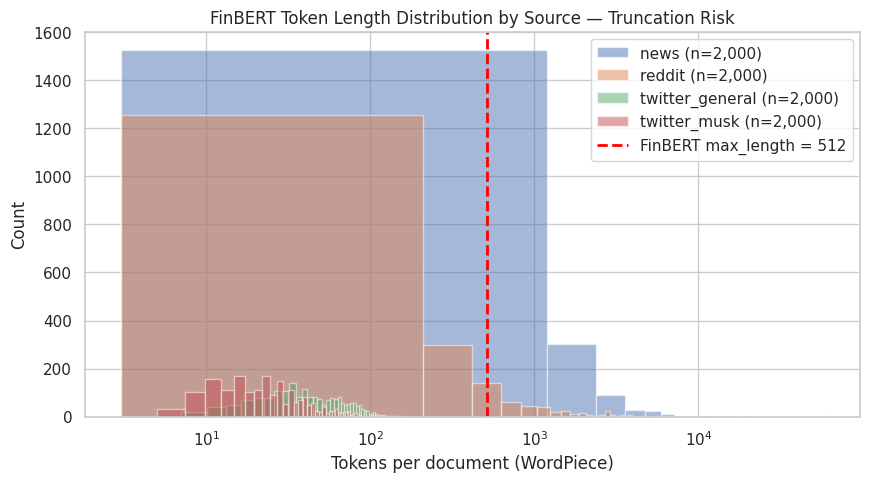

Saved: /kaggle/working/figures/06_token_lengths.png


In [7]:
# 2.2 — Visualize token length distribution per source (log scale)

fig, ax = plt.subplots(figsize=(10, 5))
for src in sorted(sample_for_len["source"].unique()):
    data = sample_for_len[sample_for_len["source"] == src]["n_finbert_tokens"]
    ax.hist(data, bins=50, alpha=0.5, label=f"{src} (n={len(data):,})")

ax.axvline(MAX_LENGTH, color="red", linestyle="--", linewidth=2,
           label=f"FinBERT max_length = {MAX_LENGTH}")
ax.set_xlabel("Tokens per document (WordPiece)")
ax.set_ylabel("Count")
ax.set_xscale("log")
ax.set_title("FinBERT Token Length Distribution by Source — Truncation Risk")
ax.legend()

fig_path = FIGURES_DIR / "06_token_lengths.png"
plt.savefig(fig_path); plt.show()
print(f"Saved: {fig_path}")

## Section 3 — Track 1: Full-Text Inference (All ~87K Documents)

The main event. I run FinBERT on the `text` column for every TSLA document, batch-processed on GPU with first-chunk truncation at 512 tokens. Chunked into 5K-row segments with Parquet checkpoints — if the kernel dies mid-run, rerunning the notebook picks up where it left off.

**Output columns:** `finbert_label`, `finbert_p_pos`, `finbert_p_neg`, `finbert_p_neu`, `finbert_confidence`, `finbert_is_confident`.


In [8]:
# 3.1 — Batched inference function

@torch.no_grad()
def finbert_infer(texts, batch_size=BATCH_SIZE):
    """Run FinBERT on a list of texts. Returns DataFrame with project-schema columns."""
    all_probs = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        enc = tokenizer(batch, return_tensors="pt", padding=True, truncation=True,
                        max_length=MAX_LENGTH).to(DEVICE)
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        all_probs.append(probs)
    all_probs = np.concatenate(all_probs, axis=0)  # shape: (n, 3) in FinBERT's native label order

    # Remap to project schema using FINBERT_COL_FOR_LABEL (built in cell 0.3)
    p_neg = all_probs[:, FINBERT_COL_FOR_LABEL["negative"]]
    p_neu = all_probs[:, FINBERT_COL_FOR_LABEL["neutral"]]
    p_pos = all_probs[:, FINBERT_COL_FOR_LABEL["positive"]]

    confidence = np.max(all_probs, axis=1)
    # Predicted label via argmax in FinBERT's native indexing, then translated
    native_pred_idx = all_probs.argmax(axis=1)
    labels = np.array([FINBERT_ID2LABEL[int(i)] for i in native_pred_idx])

    return pd.DataFrame({
        "finbert_label":        labels,
        "finbert_p_neg":        p_neg.astype(np.float32),
        "finbert_p_neu":        p_neu.astype(np.float32),
        "finbert_p_pos":        p_pos.astype(np.float32),
        "finbert_confidence":   confidence.astype(np.float32),
        "finbert_is_confident": confidence >= CONFIDENCE_THRESHOLD,
    })

# Smoke test the helper
_test_df = finbert_infer(["Tesla beat earnings.", "Tesla missed estimates.", "Tesla released a new car."])
print("Helper smoke test:")
print(_test_df.to_string())

Helper smoke test:
  finbert_label  finbert_p_neg  finbert_p_neu  finbert_p_pos  finbert_confidence  finbert_is_confident
0      positive       0.066985       0.056023       0.876992            0.876992                  True
1      negative       0.818282       0.141596       0.040122            0.818282                  True
2       neutral       0.012866       0.843315       0.143819            0.843315                  True


In [9]:
# 3.2 — Full-text inference with chunked checkpointing

n_chunks = (len(tsla) + CHUNK_SIZE - 1) // CHUNK_SIZE
print(f"Processing {len(tsla):,} documents in {n_chunks} chunks of {CHUNK_SIZE:,}")

chunk_paths = []
for i in tqdm(range(n_chunks), desc="FinBERT full-text chunks"):
    ckpt_path = CHECKPOINT_DIR / f"fulltext_chunk_{i:03d}.parquet"
    if ckpt_path.exists():
        chunk_paths.append(ckpt_path)
        continue
    start, end = i * CHUNK_SIZE, min((i + 1) * CHUNK_SIZE, len(tsla))
    chunk = tsla.iloc[start:end].reset_index(drop=True)
    preds = finbert_infer(chunk["text"].tolist())
    # Attach predictions alongside the document identifiers needed to join back
    result = pd.concat([chunk[["doc_id"]].reset_index(drop=True), preds], axis=1)
    result.to_parquet(ckpt_path, index=False)
    chunk_paths.append(ckpt_path)

print(f"\nConcatenating {len(chunk_paths)} chunks...")
fulltext_preds = pd.concat([pd.read_parquet(p) for p in chunk_paths], ignore_index=True)
print(f"Full-text predictions: {fulltext_preds.shape}")
print(f"\nLabel distribution:")
print(fulltext_preds["finbert_label"].value_counts(normalize=True).reindex(LABELS).round(3).to_string())

Processing 85,650 documents in 18 chunks of 5,000


FinBERT full-text chunks:   0%|          | 0/18 [00:00<?, ?it/s]


Concatenating 18 chunks...
Full-text predictions: (85650, 7)

Label distribution:
finbert_label
negative    0.146
neutral     0.762
positive    0.092


In [10]:
# 3.3 — Merge full-text predictions back onto the TSLA dataframe

# Deduplication — one known doc_id collision was identified during Nb06 development.
# Root cause: tweets with missing tweet_id share the placeholder URL
# "https://twitter.com/i/web/status/None", and doc_id hashing collapsed them.
# Scale: 2 duplicated rows out of ~85,650 (0.002%). Impact: negligible.
# TODO: patch doc_id generation upstream (Notebook 01) to hash text+timestamp, not URL.
n_before = len(tsla)
tsla = tsla.drop_duplicates(subset="doc_id", keep="first").reset_index(drop=True)
n_deduped_left = n_before - len(tsla)

# Dedupe the predictions too — the duplicate input produced a duplicate prediction row
fulltext_preds = fulltext_preds.drop_duplicates(subset="doc_id", keep="first").reset_index(drop=True)

if n_deduped_left > 0:
    print(f"Dropped {n_deduped_left} duplicate doc_id row(s) from tsla (kept first)")

tsla_with_finbert = tsla.merge(fulltext_preds, on="doc_id", how="left", validate="one_to_one")
assert tsla_with_finbert["finbert_label"].notna().all(), "Some rows missing FinBERT predictions"

print(f"Merged: {tsla_with_finbert.shape}")
print(f"Columns added: {[c for c in tsla_with_finbert.columns if c.startswith('finbert_')]}")

Dropped 1 duplicate doc_id row(s) from tsla (kept first)
Merged: (85649, 17)
Columns added: ['finbert_label', 'finbert_p_neg', 'finbert_p_neu', 'finbert_p_pos', 'finbert_confidence', 'finbert_is_confident']


## Section 4 — Track 2: Headline-Only Inference (News Only)

The secondary track. Run FinBERT on just the `headline` from Layer 1 news, then left-join back by `url`. Non-news rows get NULL in the headline columns. This enables the thesis experiment: *"Does FinBERT on headlines alone give a different signal than FinBERT on full content?"*


In [11]:
# 4.1 — Run FinBERT on cleaned headlines (news subset only, small — no need to chunk)

print(f"Running FinBERT on {len(news_headlines):,} unique news headlines...")
raw_headline_preds = finbert_infer(news_headlines["headline_clean"].tolist())

# Rename every finbert_* column to append '_headline' so it won't clash with full-text columns on the join
headline_preds = raw_headline_preds.rename(columns={
    "finbert_label":        "finbert_label_headline",
    "finbert_p_neg":        "finbert_p_neg_headline",
    "finbert_p_neu":        "finbert_p_neu_headline",
    "finbert_p_pos":        "finbert_p_pos_headline",
    "finbert_confidence":   "finbert_confidence_headline",
    "finbert_is_confident": "finbert_is_confident_headline",
})
headline_preds = pd.concat([news_headlines[["url"]].reset_index(drop=True), headline_preds], axis=1)

print(f"Headline predictions: {headline_preds.shape}")
print(f"\nHeadline label distribution (news only):")
print(headline_preds["finbert_label_headline"].value_counts(normalize=True).reindex(LABELS).round(3).to_string())

Running FinBERT on 42,108 unique news headlines...
Headline predictions: (42108, 7)

Headline label distribution (news only):
finbert_label_headline
negative    0.105
neutral     0.802
positive    0.093


In [12]:
# 4.2 — Left-join headline predictions by url, restricted to news rows only

# Drop any previously-joined headline columns — makes this cell safely re-runnable
# if cell 4.2 partially executed before (headline columns already leaked onto tsla_with_finbert)
existing_headline_cols = [c for c in tsla_with_finbert.columns if c.endswith("_headline")]
if existing_headline_cols:
    tsla_with_finbert = tsla_with_finbert.drop(columns=existing_headline_cols)
    print(f"Dropped {len(existing_headline_cols)} stale headline columns before re-joining")

# Pre-join sanity: no duplicate urls in headline predictions
assert headline_preds["url"].is_unique, "Duplicate urls in headline predictions — join would explode rows"

# Split news vs non-news, merge headline predictions onto news rows only, then reassemble
news_rows  = tsla_with_finbert[tsla_with_finbert["source"] == "news"].copy()
other_rows = tsla_with_finbert[tsla_with_finbert["source"] != "news"].copy()

news_rows = news_rows.merge(headline_preds, on="url", how="left", validate="many_to_one")

# Add NULL headline columns to non-news rows so concat aligns schemas
headline_cols = [c for c in news_rows.columns if c.endswith("_headline")]
for col in headline_cols:
    other_rows[col] = pd.NA

tsla_with_finbert = pd.concat([news_rows, other_rows], ignore_index=True)

# Verify the invariant now holds
news_mask = tsla_with_finbert["source"] == "news"
n_news = news_mask.sum()
n_news_with_headline    = tsla_with_finbert.loc[ news_mask, "finbert_label_headline"].notna().sum()
n_nonnews_with_headline = tsla_with_finbert.loc[~news_mask, "finbert_label_headline"].notna().sum()

print(f"News rows with a headline prediction:     {n_news_with_headline:,} / {n_news:,} "
      f"({n_news_with_headline/n_news*100:.1f}%)")
print(f"Non-news rows with a headline prediction: {n_nonnews_with_headline} (must be 0)")
assert n_nonnews_with_headline == 0, "Non-news rows STILL have headline predictions"

News rows with a headline prediction:     42,108 / 42,134 (99.9%)
Non-news rows with a headline prediction: 0 (must be 0)


In [13]:
# 4.3 — Quick headline vs full-text agreement check (news rows only)

news_rows = tsla_with_finbert[news_mask & tsla_with_finbert["finbert_label_headline"].notna()]
agree = (news_rows["finbert_label"] == news_rows["finbert_label_headline"]).mean()
print(f"Headline vs full-text agreement on news rows: {agree*100:.1f}%")
print(f"(disagreement {(1-agree)*100:.1f}% is the 'truncation impact' signal for the thesis)")

disagreement_matrix = pd.crosstab(
    news_rows["finbert_label"], news_rows["finbert_label_headline"],
    margins=False, normalize="index"
).reindex(index=LABELS, columns=LABELS).round(3)
print("\nRow-normalized disagreement matrix (rows=full-text, cols=headline):")
print(disagreement_matrix.to_string())

Headline vs full-text agreement on news rows: 78.5%
(disagreement 21.5% is the 'truncation impact' signal for the thesis)

Row-normalized disagreement matrix (rows=full-text, cols=headline):
finbert_label_headline  negative  neutral  positive
finbert_label                                      
negative                   0.423    0.468     0.109
neutral                    0.033    0.914     0.053
positive                   0.069    0.519     0.412


## Section 5 — Track 3: PhraseBank Reference Metrics

For the final thesis comparison table, I need a FinBERT number on the PhraseBank test set. Crucial disclaimer that must appear everywhere this number is cited:

> **FinBERT was fine-tuned on Financial PhraseBank training data. This metric is reported as a reference only and is NOT a fair benchmark against the classical baselines in Notebook 05.**

I reproduce the exact same 20%/80% stratified split used in Notebook 05 (same seed=42, same subset, same stratification) so the test rows are identical between notebooks.


In [14]:
# 5.1 — Reproduce the Notebook 05 test split and run FinBERT on it
# Loading PhraseBank from Kaggle dataset (same approach as Notebook 05, section 1.1)

TXT_PATH = "/kaggle/input/datasets/ankurzing/sentiment-analysis-for-financial-news/FinancialPhraseBank/Sentences_75Agree.txt"

print(f"Loading: {TXT_PATH}")
records = []
with open(TXT_PATH, encoding="latin-1") as f:
    for line in f:
        line = line.strip()
        if not line or "@" not in line:
            continue
        text, label = line.rsplit("@", 1)
        records.append({"text": text.strip(), "label": label.strip().lower()})

pb_df = pd.DataFrame(records)
pb_df["label_id"] = pb_df["label"].map(LABEL_TO_ID)

found = set(pb_df["label"].unique())
assert found.issubset(set(LABELS)), f"Unexpected labels: {found - set(LABELS)}"

# Apply the same news-cleaning used in Notebook 05 section 2.1
pb_df["text_clean"] = pb_df["text"].apply(clean_news)
pb_df = pb_df[pb_df["text_clean"].str.len() > 0].reset_index(drop=True)

# Reproduce the exact same 80/20 stratified split from Notebook 05 (seed=42, same stratify column)
# This guarantees the test rows are identical between the two notebooks.
y_all = pb_df["label"].tolist()
idx_all = np.arange(len(pb_df))
idx_train, idx_test = train_test_split(idx_all, test_size=0.20, random_state=SEED, stratify=y_all)

pb_test_text = [pb_df["text_clean"].iloc[i] for i in idx_test]
pb_test_y    = [pb_df["label"].iloc[i]      for i in idx_test]

print(f"Loaded {len(pb_df):,} sentences — test split: {len(pb_test_text):,} rows")

# Run FinBERT on the test split
print("Running FinBERT on PhraseBank test set...")
pb_preds = finbert_infer(pb_test_text)
pb_pred_labels = pb_preds["finbert_label"].tolist()

Loading: /kaggle/input/datasets/ankurzing/sentiment-analysis-for-financial-news/FinancialPhraseBank/Sentences_75Agree.txt
Loaded 3,453 sentences — test split: 691 rows
Running FinBERT on PhraseBank test set...


In [15]:
# 5.2 — Compute reference metrics, clearly labeled

p, r, f, _ = precision_recall_fscore_support(pb_test_y, pb_pred_labels, labels=LABELS,
                                              average=None, zero_division=0)
ref_metrics = {
    "accuracy":     float(accuracy_score(pb_test_y, pb_pred_labels)),
    "macro_f1":     float(f1_score(pb_test_y, pb_pred_labels, average="macro", labels=LABELS)),
    "weighted_f1":  float(f1_score(pb_test_y, pb_pred_labels, average="weighted", labels=LABELS)),
    **{f"P_{lbl}":  float(p[i]) for i, lbl in enumerate(LABELS)},
    **{f"R_{lbl}":  float(r[i]) for i, lbl in enumerate(LABELS)},
    **{f"F1_{lbl}": float(f[i]) for i, lbl in enumerate(LABELS)},
}

print("FinBERT on PhraseBank test set (REFERENCE ONLY — NOT a fair comparison)")
print("=" * 70)
print(classification_report(pb_test_y, pb_pred_labels, labels=LABELS, digits=4))
print("=" * 70)
print("⚠ FinBERT was fine-tuned on PhraseBank training data.")
print("⚠ This metric will be reported in the thesis as reference, not comparison.")

FinBERT on PhraseBank test set (REFERENCE ONLY — NOT a fair comparison)
              precision    recall  f1-score   support

    negative     0.8913    0.9762    0.9318        84
     neutral     0.9951    0.9464    0.9701       429
    positive     0.9005    0.9663    0.9322       178

    accuracy                         0.9551       691
   macro avg     0.9290    0.9630    0.9447       691
weighted avg     0.9581    0.9551    0.9557       691

⚠ FinBERT was fine-tuned on PhraseBank training data.
⚠ This metric will be reported in the thesis as reference, not comparison.


## Section 6 — Post-Inference EDA

Four analyses to produce thesis figures and empirical claims:

1. **Neutral-rate drop vs Notebook 02 baseline.** Nb02 ran FinBERT on 200 raw-text rows and got 70–84% neutral. Now after full cleaning at full scale — does the neutral rate drop, as hypothesized?
2. **Per-source label distribution.** Do sources behave differently? (Expected: news more neutral, twitter_musk more polarized.)
3. **Confidence distribution per source.** Where is FinBERT most and least certain?
4. **Musk Effect first look.** Do documents with `has_tsla_entity=True` that also reference Musk have a measurably different sentiment distribution? This is the first empirical test of the thesis's core academic claim.


In [16]:
# 6.1 — Neutral-rate drop vs Notebook 02 diagnostic baseline

# Hardcoded values from the Notebook 02 diagnostic (200-row stratified sample on raw text)
NB02_NEUTRAL_BASELINE = {
    "news":            0.70,
    "reddit":          0.78,
    "twitter_general": 0.82,
    "twitter_musk":    0.84,
}

current_neutral = tsla_with_finbert.groupby("source")["finbert_label"].apply(
    lambda s: (s == "neutral").mean()
).to_dict()

compare = pd.DataFrame({
    "nb02_raw_text_neutral_pct":     pd.Series(NB02_NEUTRAL_BASELINE) * 100,
    "current_cleaned_neutral_pct":   pd.Series(current_neutral) * 100,
}).round(1)
compare["absolute_drop_pp"] = (compare["nb02_raw_text_neutral_pct"] -
                                compare["current_cleaned_neutral_pct"]).round(1)
print("Neutral-rate comparison — raw text (Nb02) vs cleaned text (now):")
print(compare.to_string())

Neutral-rate comparison — raw text (Nb02) vs cleaned text (now):
                 nb02_raw_text_neutral_pct  current_cleaned_neutral_pct  absolute_drop_pp
news                                  70.0                         73.9              -3.9
reddit                                78.0                         80.1              -2.1
twitter_general                       82.0                         77.7               4.3
twitter_musk                          84.0                         84.9              -0.9


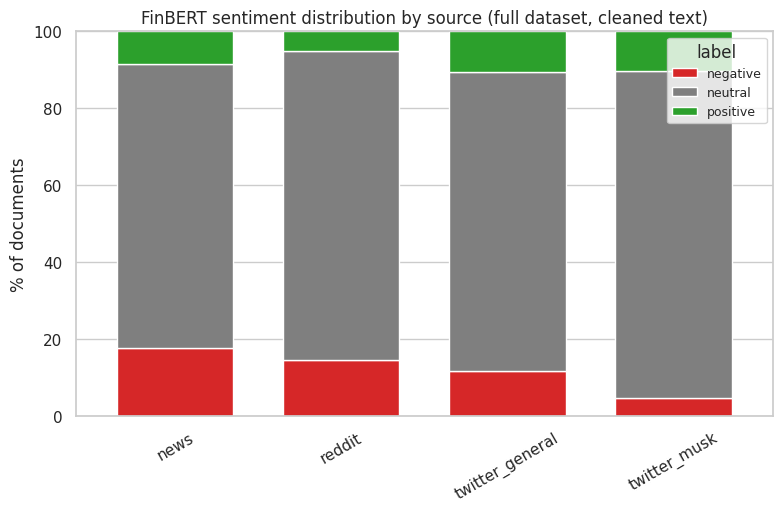

Saved: /kaggle/working/figures/06_finbert_distribution_by_source.png


In [17]:
# 6.2 — Per-source label distribution plot

dist_long = []
for src in sorted(tsla_with_finbert["source"].unique()):
    sub = tsla_with_finbert[tsla_with_finbert["source"] == src]
    for lbl in LABELS:
        dist_long.append({"source": src, "label": lbl,
                          "pct": (sub["finbert_label"] == lbl).mean() * 100})
dist_df = pd.DataFrame(dist_long)

fig, ax = plt.subplots(figsize=(9, 5))
colors_lbl = {"negative": "#d62728", "neutral": "#7f7f7f", "positive": "#2ca02c"}
pivot = dist_df.pivot(index="source", columns="label", values="pct")[LABELS]
pivot.plot(kind="bar", stacked=True, ax=ax,
           color=[colors_lbl[l] for l in LABELS], edgecolor="white", width=0.7)
ax.set_title("FinBERT sentiment distribution by source (full dataset, cleaned text)")
ax.set_ylabel("% of documents")
ax.set_xlabel("")
ax.set_ylim(0, 100)
ax.legend(title="label", loc="upper right", fontsize=9)
ax.tick_params(axis="x", rotation=30)

fig_path = FIGURES_DIR / "06_finbert_distribution_by_source.png"
plt.savefig(fig_path); plt.show()
print(f"Saved: {fig_path}")

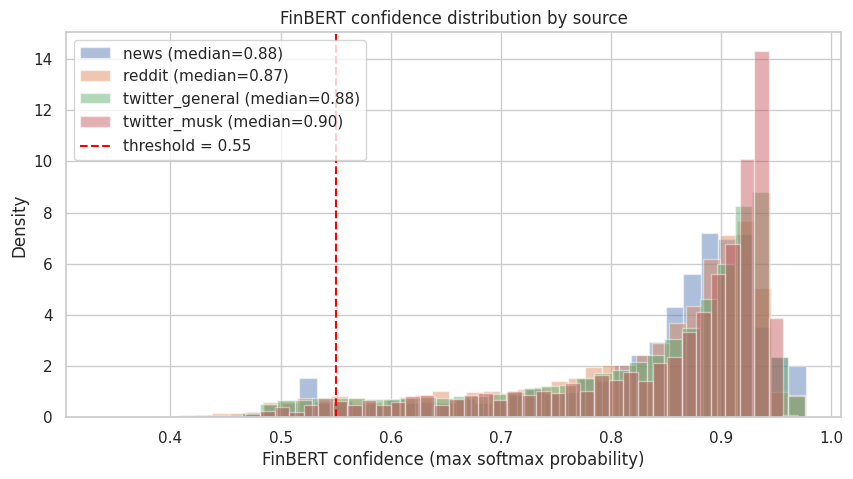

Saved: /kaggle/working/figures/06_finbert_confidence.png

Confidence stats per source:
                     n  n_confident  pct_confident
source                                            
news             42134        39579           93.9
reddit            3339         3151           94.4
twitter_general  37421        35412           94.6
twitter_musk      2755         2662           96.6


In [18]:
# 6.3 — Confidence distribution per source

fig, ax = plt.subplots(figsize=(10, 5))
for src in sorted(tsla_with_finbert["source"].unique()):
    data = tsla_with_finbert[tsla_with_finbert["source"] == src]["finbert_confidence"]
    ax.hist(data, bins=40, alpha=0.45, label=f"{src} (median={data.median():.2f})", density=True)

ax.axvline(CONFIDENCE_THRESHOLD, color="red", linestyle="--", linewidth=1.5,
           label=f"threshold = {CONFIDENCE_THRESHOLD}")
ax.set_xlabel("FinBERT confidence (max softmax probability)")
ax.set_ylabel("Density")
ax.set_title("FinBERT confidence distribution by source")
ax.legend()

fig_path = FIGURES_DIR / "06_finbert_confidence.png"
plt.savefig(fig_path); plt.show()
print(f"Saved: {fig_path}")

# Per-source % above threshold
conf_stats = tsla_with_finbert.groupby("source")["finbert_is_confident"].agg(
    n="count", n_confident="sum", pct_confident=lambda x: x.mean() * 100
).round(1)
print("\nConfidence stats per source:")
print(conf_stats.to_string())

In [19]:
# 6.4 — Musk Effect first look

# Look for Musk mentions in entities JSON (if present) or text directly
if "entities" in tsla_with_finbert.columns:
    def mentions_musk_entities(ent_json):
        if not isinstance(ent_json, str) or not ent_json:
            return False
        try:
            ents = json.loads(ent_json)
            return any(("musk" in e.get("text", "").lower() or "elon" in e.get("text", "").lower())
                       and e.get("label") == "PERSON" for e in ents)
        except Exception:
            return False
    tsla_with_finbert["mentions_musk"] = tsla_with_finbert["entities"].apply(mentions_musk_entities)
else:
    tsla_with_finbert["mentions_musk"] = tsla_with_finbert["text"].str.lower().str.contains(
        r"\bmusk\b|\belon\b", regex=True, na=False
    )

# Exclude twitter_musk source itself — of course those tweets mention Musk
non_musk_src = tsla_with_finbert[tsla_with_finbert["source"] != "twitter_musk"]
with_musk   = non_musk_src[non_musk_src["mentions_musk"]]
without_musk = non_musk_src[~non_musk_src["mentions_musk"]]

def dist_pct(df):
    return (df["finbert_label"].value_counts(normalize=True).reindex(LABELS) * 100).round(1)

musk_table = pd.DataFrame({
    f"Mentions Musk  (n={len(with_musk):,})":       dist_pct(with_musk),
    f"No Musk        (n={len(without_musk):,})":    dist_pct(without_musk),
})
musk_table["Δ (pp)"] = (musk_table.iloc[:, 0] - musk_table.iloc[:, 1]).round(1)
print("Sentiment distribution — Musk-mentioning vs not (excluding twitter_musk source):")
print(musk_table.to_string())
print("\nΔ > 0 means Musk-mentioning docs lean more toward that label.")

Sentiment distribution — Musk-mentioning vs not (excluding twitter_musk source):
               Mentions Musk  (n=17,077)  No Musk        (n=65,817)  Δ (pp)
finbert_label                                                              
negative                            27.2                       11.8    15.4
neutral                             63.8                       79.0   -15.2
positive                             9.1                        9.2    -0.1

Δ > 0 means Musk-mentioning docs lean more toward that label.


## Section 7 — Save Outputs

Persist the final dataset, the reference metrics JSON, and print the summary.


In [20]:
# 7.1 — Save layer2_sentiment_finbert.parquet

OUTPUT_PATH = DATA_DIR / "layer2_sentiment_finbert.parquet"
tsla_with_finbert.to_parquet(OUTPUT_PATH, index=False)

finbert_cols = [c for c in tsla_with_finbert.columns if c.startswith("finbert_")]
print(f"Saved: {OUTPUT_PATH}")
print(f"Rows:  {len(tsla_with_finbert):,}")
print(f"Cols:  {len(tsla_with_finbert.columns)}")
print(f"\nFinBERT columns added ({len(finbert_cols)}):")
for c in finbert_cols:
    print(f"  {c}")

Saved: /kaggle/working/data/layer2_sentiment_finbert.parquet
Rows:  85,649
Cols:  24

FinBERT columns added (12):
  finbert_label
  finbert_p_neg
  finbert_p_neu
  finbert_p_pos
  finbert_confidence
  finbert_is_confident
  finbert_label_headline
  finbert_p_neg_headline
  finbert_p_neu_headline
  finbert_p_pos_headline
  finbert_confidence_headline
  finbert_is_confident_headline


In [21]:
# 7.2 — Save finbert_eval.json with all metrics, config, and distributions

def to_jsonable(obj):
    if isinstance(obj, (np.integer,)):  return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, (np.bool_,)):    return bool(obj)
    if isinstance(obj, np.ndarray):     return obj.tolist()
    if isinstance(obj, dict):           return {k: to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):  return [to_jsonable(v) for v in obj]
    return obj

eval_results = {
    "run_timestamp": RUN_TS,
    "seed": SEED,
    "library_versions": VERSIONS,
    "model": {
        "name":                   FINBERT_MODEL,
        "max_length":             MAX_LENGTH,
        "batch_size":             BATCH_SIZE,
        "device":                 str(DEVICE),
        "confidence_threshold":   CONFIDENCE_THRESHOLD,
        "native_label_mapping":   FINBERT_ID2LABEL,
        "project_col_for_label":  FINBERT_COL_FOR_LABEL,
    },
    "inputs": {
        "layer2": str(LAYER2_INPUT),
        "layer1_news": str(LAYER1_NEWS_INPUT),
    },
    "fulltext_inference": {
        "n_documents": len(tsla_with_finbert),
        "label_distribution_pct": {
            l: float((tsla_with_finbert["finbert_label"] == l).mean() * 100) for l in LABELS
        },
        "confidence_stats_per_source": conf_stats.to_dict(orient="index"),
        "neutral_rate_vs_nb02": compare.to_dict(orient="index"),
    },
    "headline_inference": {
        "n_news_documents_with_headline": int(n_news_with_headline),
        "news_coverage_pct": float(n_news_with_headline / max(n_news, 1) * 100),
        "headline_vs_fulltext_agreement_pct": float(agree * 100),
    },
    "phrasebank_reference_NOT_fair_comparison": {
        "warning":  "FinBERT was fine-tuned on PhraseBank training data. "
                    "This metric is a reference only, not a fair benchmark.",
        "test_rows": len(pb_test_text),
        "metrics":   ref_metrics,
    },
    "musk_effect_first_look": {
        "excludes_source": "twitter_musk",
        "with_musk":       dist_pct(with_musk).to_dict(),
        "without_musk":    dist_pct(without_musk).to_dict(),
    },
    "output_dataset": str(OUTPUT_PATH),
    "figures": [str(p) for p in sorted(FIGURES_DIR.glob("06_*.png"))],
}

results_path = RESULTS_DIR / "finbert_eval.json"
with open(results_path, "w") as f:
    json.dump(to_jsonable(eval_results), f, indent=2, default=str)

print(f"Saved: {results_path}")

Saved: /kaggle/working/results/finbert_eval.json


## Section 8 — Summary and Bridge to Notebook 07

### What was produced

- `layer2_sentiment_finbert.parquet` with all ~87K documents + FinBERT labels/probabilities/confidence + headline-track predictions joined in for news rows.
- `finbert_eval.json` with PhraseBank reference metrics (flagged as reference-not-comparison), per-source distributions, Musk Effect first look, and full model config.
- Three thesis-quality figures: token length distribution, source-wise sentiment distribution, confidence distribution.
- A headline-vs-full-content agreement number ready to cite in the thesis.

### Limitations to document in the thesis

1. **Truncation at 512 tokens** affects long news articles. The headline track in this notebook is the partial mitigation: we now have both "first-512-tokens" and "headline-only" signals for every news document.
2. **FinBERT is pretrained on generic financial news**, not Tesla-specific language. Out-of-domain behavior on the noisier sources (Reddit, Twitter) is measured in Notebook 07 against manual labels.
3. **PhraseBank reference is not a comparison.** FinBERT saw PhraseBank training data during fine-tuning. The fair comparison is on the manually-labeled TSLA sample in Notebook 07.
4. **Musk Effect first look is descriptive, not causal.** The sentiment-distribution difference between Musk-mentioning and non-mentioning documents reported in section 6.4 is a hypothesis generator, not a test. Causal inference happens in Step 5 with price data.

### Next steps

- **Notebook 07** — `07_sentiment_comparison.ipynb`: merge `layer2_sentiment_baselines.parquet` (from Nb05) and `layer2_sentiment_finbert.parquet` (from this notebook) on `doc_id`. Manually label 200–300 TSLA documents, stratified per source. Compute macro-F1 for all four models on that set with bootstrap CIs. Cohen's kappa for inter-model agreement. This is the definitive sentiment-model comparison for the thesis.
- **Then Step 4**: sentiment aggregation into daily indices, join with yfinance OHLCV, build the feature matrix for Step 5.
